In [ ]:
import re
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, norm, laplace


PKL_BASE = Path(r"./Data/prosodic_features_splits_CLEANED")
LOSS_BASE = Path(r"./losses_cm_CLEAN")

TARGET_SPLIT = "remission_N"  
# options: "full", "healthy", "depression", "psychosis", "remission_Y", "remission_N"

features = [
    "absolute_prominence",
    "relative_prominence",
    "duration",
    "loudness",
    "pause",
    "pitch",
]

names = {
    "absolute_prominence": "prom_abs",
    "relative_prominence": "prom_rel",
    "duration": "duration",
    "loudness": "intensity",
    "pause": "pause",
    "pitch": "f0_dct",
}

featplotdict = {
    "absolute_prominence": "Absolute Prominence",
    "relative_prominence": "Relative Prominence",
    "duration": "Duration",
    "loudness": "Loudness",
    "pause": "Pause",
    "pitch": "Pitch",
}

family_by_feature = {
    "absolute_prominence": "gamma",
    "relative_prominence": "gaussian",
    "duration": "gaussian",
    "loudness": "gaussian",
    "pause": "gamma",
    "pitch": "independent_laplace",
}

test_file_by_split = {
    "full": "test.pkl",
    "healthy": "test_healthy.pkl",
    "depression": "test_depression.pkl",
    "psychosis": "test_psychosis.pkl",
    "remission_Y": "test_psychosis_remission_Y.pkl",
    "remission_N": "test_psychosis_remission_N.pkl",
}

test_loss_subdir_by_split = {
    "full": "FULL-TEST",
    "healthy": "HEALTHY-TEST",
    "depression": "DEPRESSION-TEST",
    "psychosis": "PSYCHOSIS-TEST",
    "remission_Y": "REMISSION_Y-TEST",
    "remission_N": "REMISSION_N-TEST",
}


# helpers

def load_labels_auto(pkl_path):
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    rows = []
    for seq in data["labels"]:
        for y in seq:
            arr = np.asarray(y, dtype=float)

            if arr.ndim == 0:
                rows.append(float(arr))
            elif arr.ndim == 1:
                rows.append(arr)
            else:
                raise ValueError(f"Unexpected label shape {arr.shape} in {pkl_path}")

    x = np.asarray(rows, dtype=float)

    if x.ndim == 1:
        return x[np.isfinite(x)]

    if x.ndim == 2:
        return x[np.isfinite(x).all(axis=1)]

    raise ValueError(f"Unexpected final shape {x.shape}")


def estimate_unconditional_nll(train_x, test_x, family, eps=1e-4):
    train_x = np.asarray(train_x, dtype=float)
    test_x = np.asarray(test_x, dtype=float)

    if family == "gaussian":
        mu = float(np.mean(train_x))
        sigma = max(float(np.std(train_x)), eps)
        return float(-np.mean(norm.logpdf(test_x, loc=mu, scale=sigma)))

    if family == "gamma":
        train_pos = np.clip(train_x, eps, None)
        test_pos = np.clip(test_x, eps, None)
        shape, loc, scale = gamma.fit(train_pos, floc=0)
        return float(-np.mean(gamma.logpdf(test_pos, shape, loc=loc, scale=scale)))

    if family == "independent_laplace":
        loc = np.median(train_x, axis=0)
        scale = np.mean(np.abs(train_x - loc), axis=0)
        scale = np.maximum(scale, eps)

        logp = laplace.logpdf(test_x, loc=loc, scale=scale)
        return float(-np.mean(np.sum(logp, axis=1)))

    raise ValueError(f"Unknown family: {family}")


def safe_avg(loss_sum, freq):
    freq = freq.astype(float)
    freq = np.where(freq == 0, np.nan, freq)
    return loss_sum / freq


def infer_best_epoch(feature):
    folder = LOSS_BASE / names[feature]
    candidates = sorted(folder.glob("train_sum*.npy"))

    best_epoch = None
    best_loss = np.inf

    for p in candidates:
        m = re.search(r"train_sum(\d+)\.npy$", p.name)
        if not m:
            continue

        epoch = int(m.group(1))
        freq_path = folder / f"train_freqs{epoch}.npy"

        if not freq_path.exists():
            continue

        loss_sum = np.load(p)
        freq = np.load(freq_path)

        global_loss = np.nansum(loss_sum) / np.nansum(freq)

        if global_loss < best_loss:
            best_loss = global_loss
            best_epoch = epoch

    if best_epoch is None:
        raise RuntimeError(f"No train_sum/train_freqs files found for {feature}")

    return best_epoch, best_loss


def load_train_loss(feature):
    epoch, global_loss = infer_best_epoch(feature)
    folder = LOSS_BASE / names[feature]

    loss_sum = np.load(folder / f"train_sum{epoch}.npy")
    freq = np.load(folder / f"train_freqs{epoch}.npy")

    return {
        "feature": feature,
        "epoch": epoch,
        "loss_sum": loss_sum,
        "freq": freq,
        "avg_loss": safe_avg(loss_sum, freq),
        "global_loss": global_loss,
        "loss_dir": folder,
    }


def load_test_loss(feature, split):
    folder = LOSS_BASE / names[feature] / test_loss_subdir_by_split[split]

    loss_sum = np.load(folder / "test_sum.npy")
    freq = np.load(folder / "test_freqs.npy")

    return {
        "feature": feature,
        "loss_sum": loss_sum,
        "freq": freq,
        "avg_loss": safe_avg(loss_sum, freq),
        "global_loss": np.nansum(loss_sum) / np.nansum(freq),
        "loss_dir": folder,
    }


def plot_heatmap(matrix, title, cmap="cool", vmin=None, vmax=None):
    fig, ax = plt.subplots(figsize=(12, 12))
    im = ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            val = matrix[i, j]
            txt = "nan" if np.isnan(val) else f"{val:.2f}"

            ax.text(
                j,
                i,
                txt,
                ha="center",
                va="center",
                color="w",
                fontsize=15,
            )

    plt.colorbar(im)
    plt.xlabel("Words to the right", fontsize=20)
    plt.ylabel("Words to the left", fontsize=20)
    plt.title(title, fontsize=20)
    plt.show()

def get_mi_map(feature=None, split_type="test", clipped=False):
    """
    feature=None gives average MI across all features.
    feature='pitch', 'duration', etc. gives feature-specific MI.
    split_type='test' or 'train'.
    clipped=True uses non-negative clipped MI.
    """
    key = "mi_clipped" if clipped else "mi"

    if split_type == "test":
        results = test_results_plot
        avg_map = all_avg_mi_test_clipped if clipped else all_avg_mi_test
    elif split_type == "train":
        results = train_results_plot
        avg_map = all_avg_mi_train_clipped if clipped else all_avg_mi_train
    else:
        raise ValueError("split_type must be 'test' or 'train'")

    if feature is None:
        return avg_map

    return results[feature][key]


def plot_mi(feature=None, split_type="test", clipped=False, cmap="cool", vmin=None, vmax=None):
    matrix = get_mi_map(
        feature=feature,
        split_type=split_type,
        clipped=clipped,
    )

    clip_txt = "Clipped " if clipped else ""
    data_txt = split_type.capitalize()

    if feature is None:
        title = (
            f"{clip_txt}Average Mutual Information All Features\n"
            f"Speech {data_txt} Data: {TARGET_SPLIT.upper()}"
        )
    else:
        title = (
            f"{clip_txt}Mutual Information: {featplotdict[feature]}\n"
            f"Speech {data_txt} Data: {TARGET_SPLIT.upper()}"
        )

    plot_heatmap(matrix, title, cmap=cmap, vmin=vmin, vmax=vmax)

# compute unconditional and conditional NLL for selected split

unconditional_nll = {}
train_results_plot = {}
test_results_plot = {}

print(f"Computing MI maps for split: {TARGET_SPLIT.upper()}")

for feature in features:
    train_x = load_labels_auto(PKL_BASE / feature / "train.pkl")
    test_x = load_labels_auto(PKL_BASE / feature / test_file_by_split[TARGET_SPLIT])

    family = family_by_feature[feature]
    entropy = estimate_unconditional_nll(train_x, test_x, family)

    train_loss = load_train_loss(feature)
    test_loss = load_test_loss(feature, TARGET_SPLIT)

    train_mi = entropy - train_loss["avg_loss"]
    test_mi = entropy - test_loss["avg_loss"]

    unconditional_nll[feature] = entropy

    train_results_plot[feature] = {
        **train_loss,
        "entropy": entropy,
        "mi": train_mi,
        "mi_clipped": np.maximum(train_mi, 0),
        "global_mi": entropy - train_loss["global_loss"],
    }

    test_results_plot[feature] = {
        **test_loss,
        "entropy": entropy,
        "mi": test_mi,
        "mi_clipped": np.maximum(test_mi, 0),
        "global_mi": entropy - test_loss["global_loss"],
    }

    print(
        f"{feature:22s} "
        f"H={entropy:.3f} | "
        f"test loss={test_loss['global_loss']:.3f} | "
        f"test MI={test_results_plot[feature]['global_mi']:.3f}"
    )


# avg maps

all_avg_mi_train = np.mean(
    [train_results_plot[f]["mi"] for f in features],
    axis=0,
)

all_avg_mi_test = np.mean(
    [test_results_plot[f]["mi"] for f in features],
    axis=0,
)

all_avg_mi_train_clipped = np.mean(
    [train_results_plot[f]["mi_clipped"] for f in features],
    axis=0,
)

all_avg_mi_test_clipped = np.mean(
    [test_results_plot[f]["mi_clipped"] for f in features],
    axis=0,
)

print("\nReady.")
print("Use `all_avg_mi_test` for the average test MI heatmap.")
print("Use plot_heatmap(clipped=True), to plot clipped heatmap (negative MI clipped to 0)")

Computing MI maps for split: REMISSION_N
absolute_prominence    H=-1.050 | test loss=-1.247 | test MI=0.197
relative_prominence    H=-0.335 | test loss=-0.456 | test MI=0.121
duration               H=-0.118 | test loss=-0.392 | test MI=0.273
loudness               H=1.419 | test loss=1.341 | test MI=0.078
pause                  H=-4.632 | test loss=-4.509 | test MI=-0.122
pitch                  H=5.285 | test loss=5.086 | test MI=0.200

Ready.
Use `all_avg_mi_test` for the average test MI heatmap.
Use plot_heatmap(clipped=True), to plot clipped heatmap (negative MI clipped to 0)


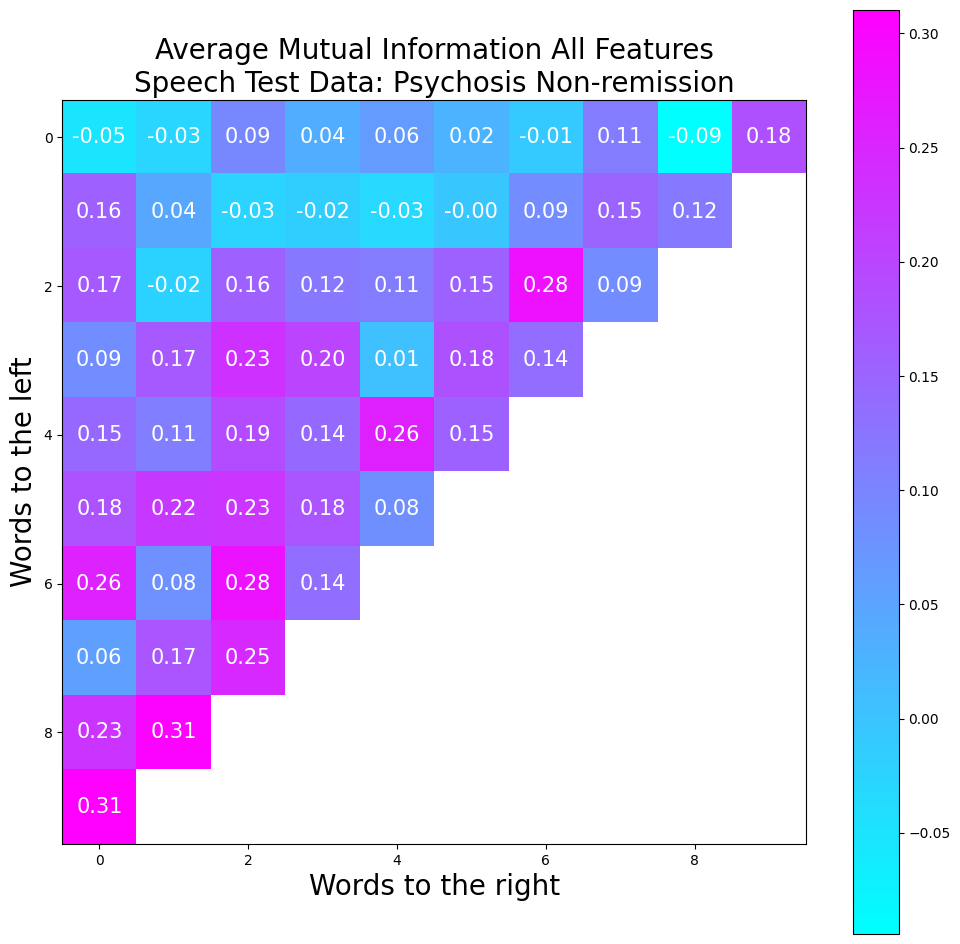

In [ ]:
plot_heatmap(
    all_avg_mi_test,
    f"Average Mutual Information All Features\nSpeech Test Data: {TARGET_SPLIT.upper()}",
    #f"Average Mutual Information All Features\nSpeech Test Data: Psychosis Remission"
    #f"Average Mutual Information All Features\nSpeech Test Data: Psychosis Non-remission"
)

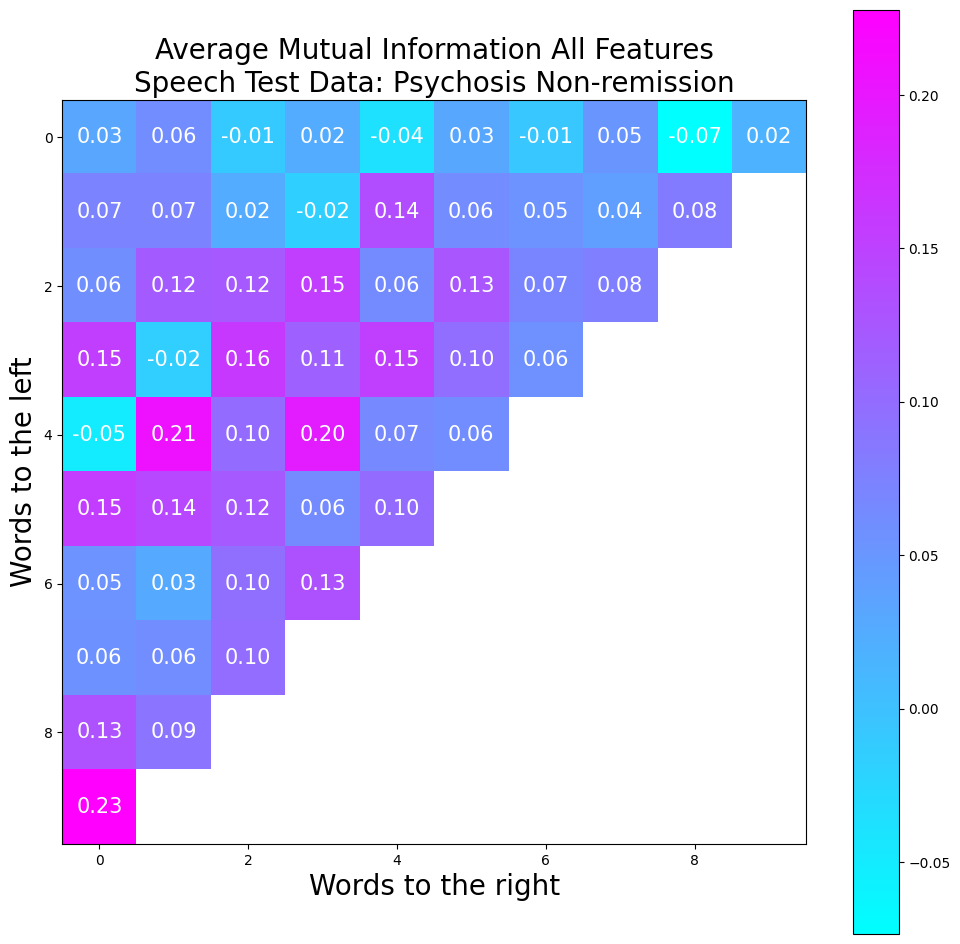

In [ ]:
feature = "loudness"

plot_heatmap(
    test_results_plot[feature]["mi"],
    f"Mutual Information: {featplotdict[feature]}\nSpeech Test Data: {TARGET_SPLIT.upper()}",
    #f"Mutual Information: {featplotdict[feature]}\nSpeech Test Data: Psychosis Remission",
    #f"Average Mutual Information All Features\nSpeech Test Data: Psychosis Non-remission"
)

### For plotting clipped heatmaps where interpretability is low due to outliers

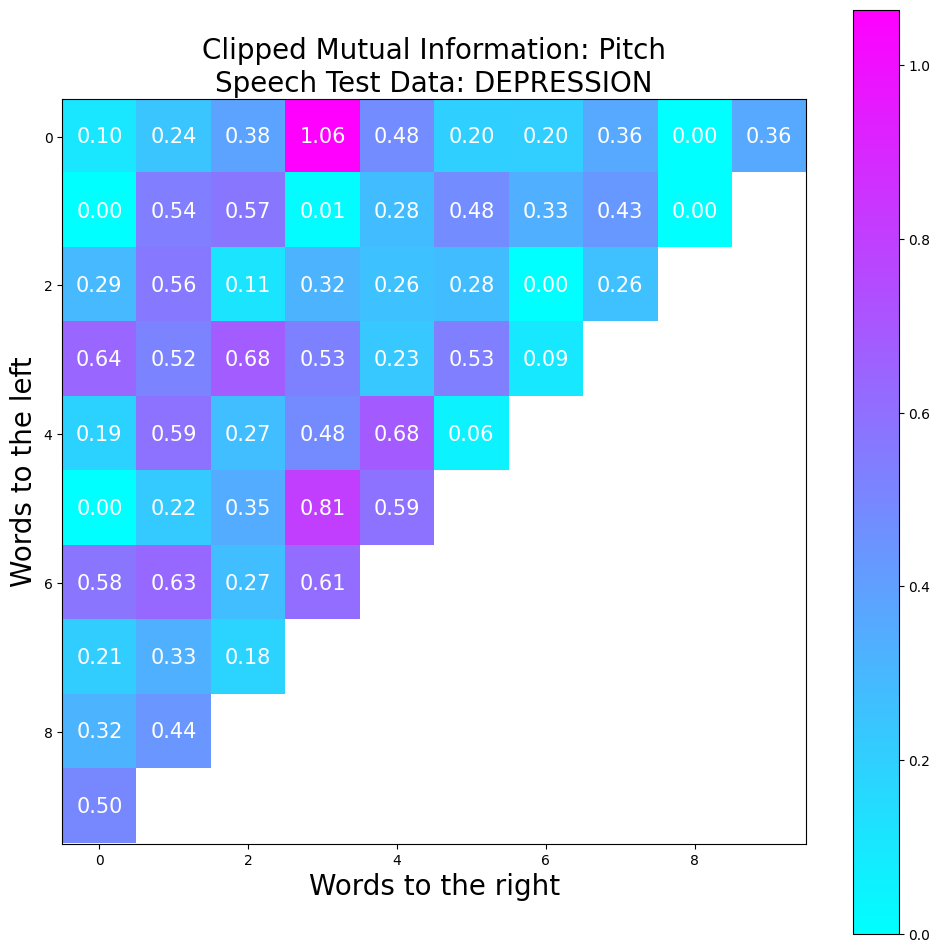

In [29]:
plot_mi(
    feature="pitch",
    clipped=True,
)

### For training data - only relevant for the full split

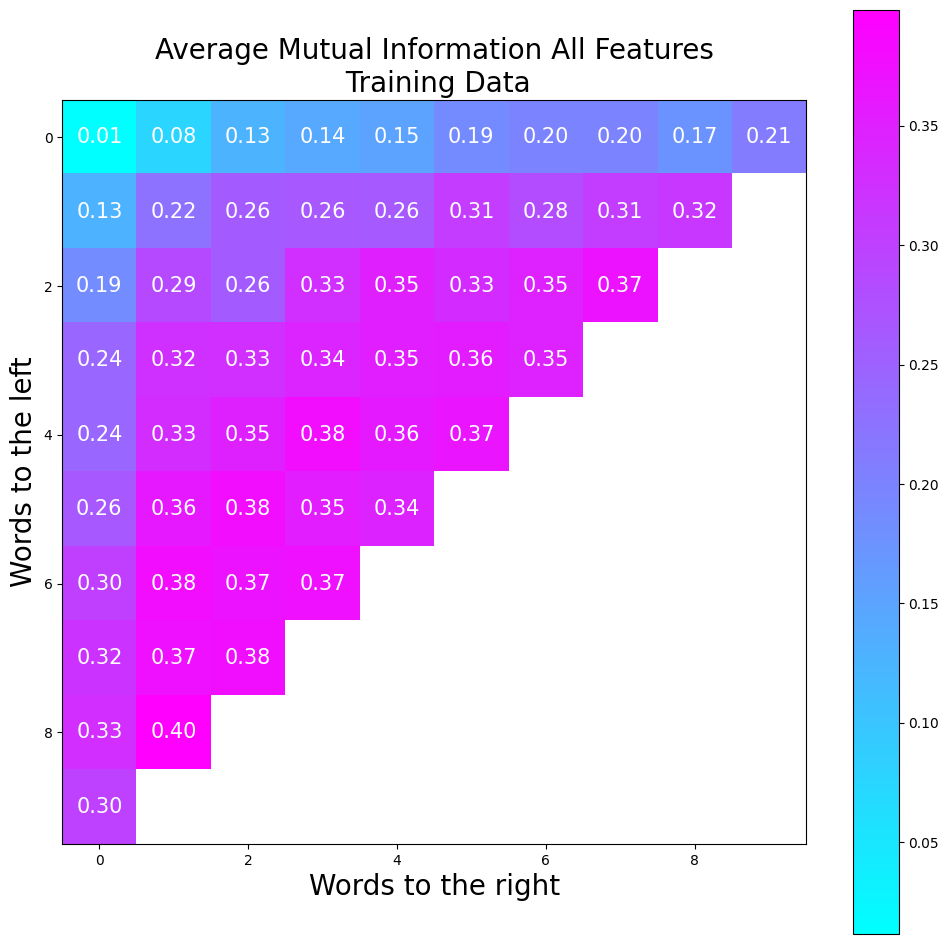

In [7]:
plot_heatmap(
    all_avg_mi_train,
    f"Average Mutual Information All Features\n Training Data",
)

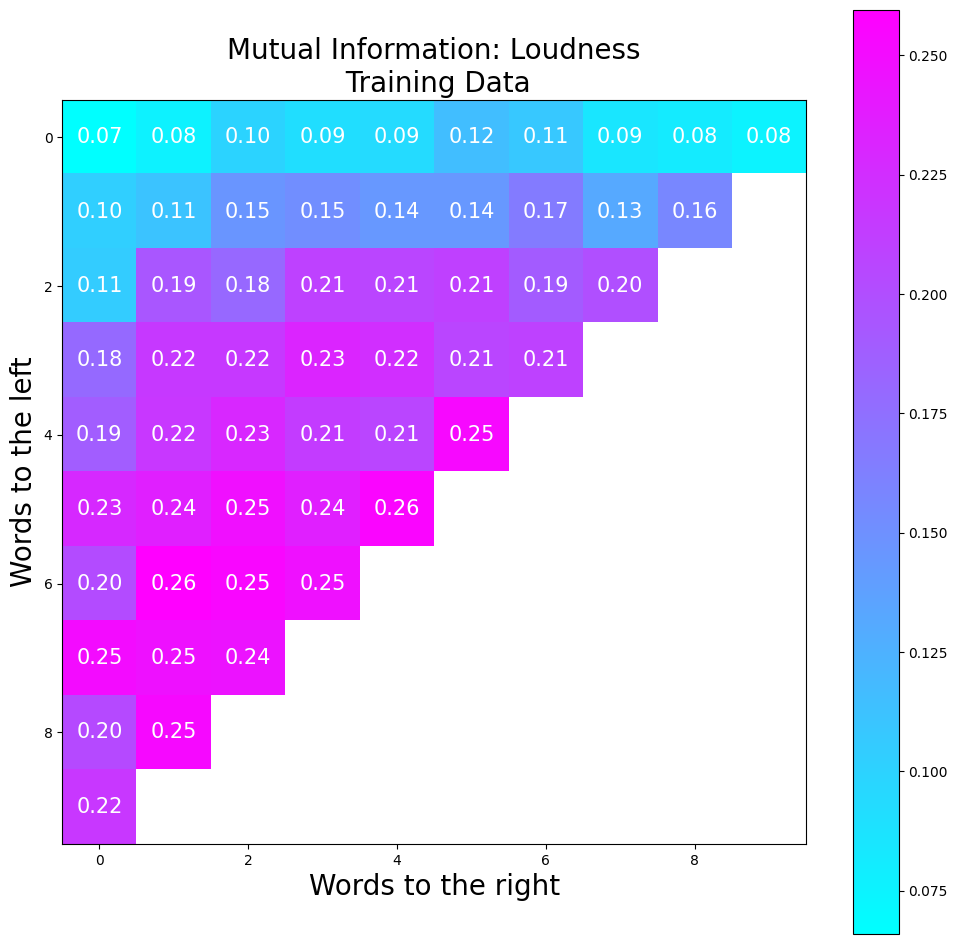

In [14]:
feature = "loudness"

plot_heatmap(
    train_results_plot[feature]["mi"],
    f"Mutual Information: {featplotdict[feature]}\n Training Data",
)